Exploratory Data Analysis

In [1]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [2]:
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Filter for India Data Analyst role

In [3]:
df_India_DA = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

Text(0, 0.5, '')

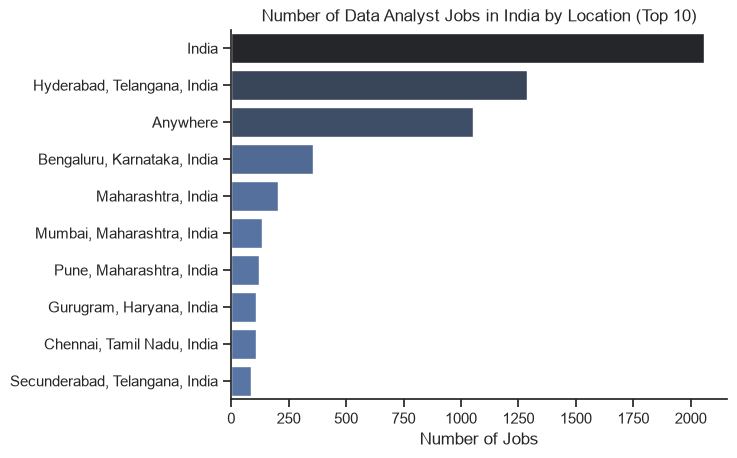

In [4]:
df_plot = df_India_DA['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data = df_plot, x='count', y='job_location', hue='count', palette = 'dark:b_r', legend=False)
sns.despine()
plt.title('Number of Data Analyst Jobs in India by Location (Top 10)')
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('')


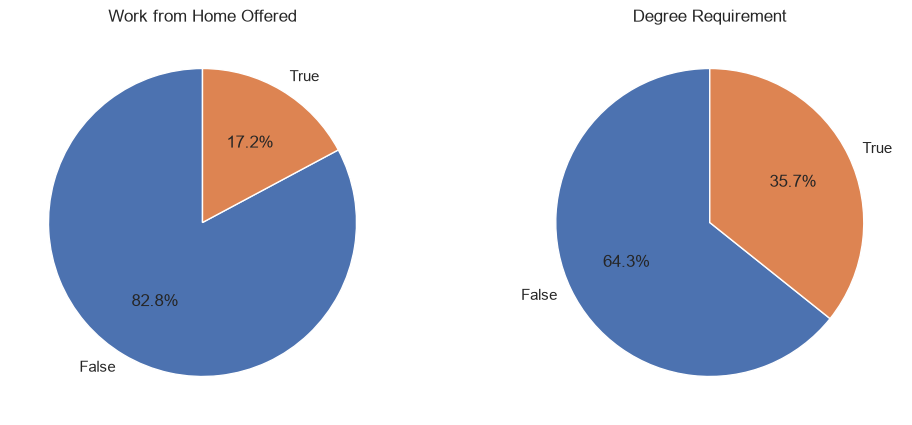

In [5]:
#above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement'
}

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 5)

for i, (column, title) in enumerate(dict_column.items()):
    value_counts = df_India_DA[column].value_counts()
    ax[i].pie(value_counts, labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

Text(0, 0.5, '')

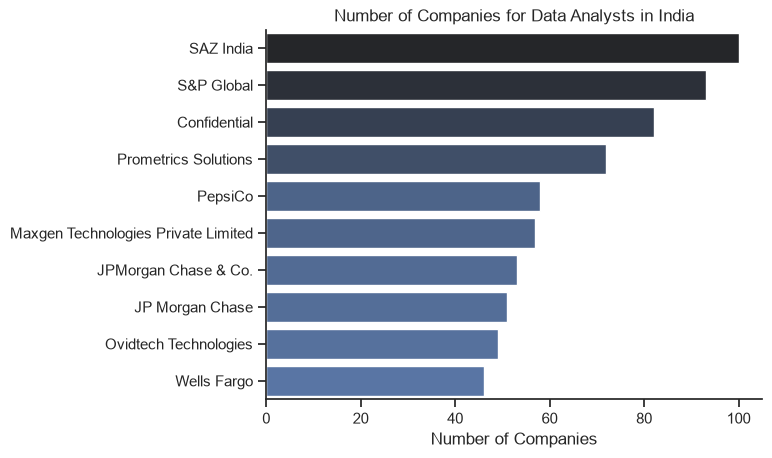

In [6]:
df_plot = df_India_DA['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data = df_plot, x='count', y='company_name', hue='count', palette = 'dark:b_r', legend=False)
sns.despine()
plt.title('Number of Companies for Data Analysts in India')
plt.xlabel('Number of Companies', fontsize=12)
plt.ylabel('')